In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Preprocessing

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.5 MB/s eta 0:00:00


# CNN


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report
import pydicom
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
import cv2
import ast
from torch.utils.data import Sampler
import random

Carica il dataset tramite il file csv.
Crea un dizionario con:
Paziente : { slope, intercept, slices, weeks, fvcs }.
Genera lo split dei pazienti in train/val/test, curante nel non dividere dati dei pazienti stessi.

In [ ]:
class IPFDataLoader:
    """Carica e prepara i dati dal CSV"""

    def __init__(self, csv_path: str,npy_dir:str):
        """
        Args:
            csv_path: Path al CSV con [Patient, Weeks, FVC, Slice_files, FVC slope, FVC intercept0]
        """
        self.df = pd.read_csv(csv_path)
        self.npy_dir = npy_dir
        print(f"✅ Loaded {len(self.df)} records from CSV")
        print(f"✅ Unique patients in CSV: {self.df['Patient'].nunique()}")
        print(f"✅ NPY directory: {npy_dir}")
        print(f"📋 Columns: {self.df.columns.tolist()}")

        # Verifica che i pazienti nel CSV abbiano cartelle NPY
        self._verify_npy_availability()

    def _verify_npy_availability(self):
        """Verifica che ogni paziente nel CSV abbia una cartella con file .npy"""
        patients_csv = set(self.df['Patient'].unique())
        patients_npy = set([d for d in os.listdir(self.npy_dir)
                           if os.path.isdir(os.path.join(self.npy_dir, d))])

        missing = patients_csv - patients_npy
        extra = patients_npy - patients_csv

        if missing:
            print(f"⚠️  {len(missing)} pazienti nel CSV senza cartella NPY: {list(missing)[:5]}...")
        if extra:
            print(f"ℹ️  {len(extra)} cartelle NPY non nel CSV (verranno ignorate)")

        available = patients_csv & patients_npy
        print(f"✅ {len(available)} pazienti con dati completi (CSV + NPY)")



    def get_patient_data(self) -> Dict[str, Dict]:
        """
        Organizza i dati per paziente

        Returns:
            {patient_id: {
                'slope': float,
                'intercept': float,
                'slices': [list_of_slice_paths],
                'weeks': [list_of_weeks],
                'fvc_values': [list_of_fvc]
            }}
        """
        patient_data = {}

        for patient_id in self.df['Patient'].unique():
            patient_df = self.df[self.df['Patient'] == patient_id].sort_values('Weeks')

            # Slope e Intercept FVC (costanti per paziente)
            slope = patient_df['fvc_slope'].iloc[0]
            intercept = patient_df['fvc_intercept0'].iloc[0]

            # Baseline (prima misurazione) -> Firstly use intercept a t=0
            #baseline_week = patient_df['Week'].iloc[0]
            #baseline_fvc = patient_df['FVC'].iloc[0]

            patient_npy_folder = os.path.join(self.npy_dir, patient_id)

            if not os.path.exists(patient_npy_folder):
                print(f"⚠️  Cartella NPY non trovata per {patient_id}, paziente saltato")
                continue

            # Ottieni tutti i file .npy ordinati
            npy_files = sorted(glob.glob(os.path.join(patient_npy_folder, "*.npy")))

            if not npy_files:
                print(f"⚠️  Nessun file NPY trovato per {patient_id}, paziente saltato")
                continue


            # Timeline completa
            weeks = patient_df['Weeks'].tolist()
            fvc_values = patient_df['FVC'].tolist()

            patient_data[patient_id] = {
                'slope': slope,
                'intercept': intercept,
                'slices': npy_files,
                'n_slices':len(npy_files),
                'weeks': weeks,
                'fvc_values': fvc_values
            }

        print(f"\n📊 Patient data prepared for {len(patient_data)} patients")

        # Statistiche sulle slice
        slice_counts = [data['n_slices'] for data in patient_data.values()]
        print(f"   Min slices: {min(slice_counts)}")
        print(f"   Max slices: {max(slice_counts)}")
        print(f"   Avg slices: {np.mean(slice_counts):.2f}")



        return patient_data

    def split_patients(self, test_size=0.2, val_size=0.1, random_state=42):
        """
        Split a livello di PAZIENTE per evitare data leakage

        Returns:
            train_patients, val_patients, test_patients (liste di patient IDs)
        """
        # Solo pazienti che hanno sia dati CSV che cartella NPY
        patient_npy_folders = set([d for d in os.listdir(self.npy_dir)
                                   if os.path.isdir(os.path.join(self.npy_dir, d))])
        csv_patients = set(self.df['Patient'].unique())

        valid_patients = np.array(list(csv_patients & patient_npy_folders))

        print(f"\n🔄 Splitting {len(valid_patients)} valid patients...")

        # Prima split: Train+Val vs Test
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_val_idx, test_idx = next(splitter.split(valid_patients, groups=valid_patients))

        train_val_patients = valid_patients[train_val_idx]
        test_patients = valid_patients[test_idx]

        # Seconda split: Train vs Val
        val_size_adjusted = val_size / (1 - test_size)
        splitter = GroupShuffleSplit(n_splits=1, test_size=val_size_adjusted, random_state=random_state)
        train_idx, val_idx = next(splitter.split(train_val_patients, groups=train_val_patients))

        train_patients = train_val_patients[train_idx]
        val_patients = train_val_patients[val_idx]

        print(f"✅ Data Split:")
        print(f"   Train: {len(train_patients)} patients")
        print(f"   Val: {len(val_patients)} patients")
        print(f"   Test: {len(test_patients)} patients")

        return train_patients.tolist(), val_patients.tolist(), test_patients.tolist()




    def __len__(self):
        return len(self.df)



In [ ]:
class IPFSliceDataset(Dataset):
    """Dataset che carica singole slice DICOM con slope come label"""

    def __init__(self, patient_list: List[str], patient_data: Dict,
                 transform=None, normalize_slope=True, image_size=(224, 224)):
        """
        Args:
            patient_list: Lista di patient IDs da includere (based on split)
            patient_data: Dict da IPFDataLoader.get_patient_data()
            transform: Trasformazioni immagini
            normalize_slope: Se normalizzare gli slope
            image_size: Dimensione target (H, W)
        """
        self.data = []
        self.slopes = []
        self.image_size = image_size
        self.transform = transform
        self._cache = {}

        # Crea lista (patient_id, slice_path, slope)
        for patient_id in patient_list:
            if patient_id not in patient_data:
                continue

            #Extracts data from dictionary
            pdata = patient_data[patient_id]
            #Slope
            slope = pdata['slope']

            slices = pdata['slices']
            weeks = pdata['weeks']

            for slice_path in slices:
              self.data.append({
                  'patient_id':patient_id,
                  'slice_path':slice_path,
                  'slope':float(slope),
                  'intercept':float(pdata.get('intercept',0.0)),
              })
              self.slopes.append(float(slope))

        #Mappa : paziente -> indice delle sue slices nel dataset

        self.patient_to_indices = defaultdict(list)
        for idx, item in enumerate(self.data):
          self.patient_to_indices[item['patient_id']].append(idx)
        self.patients = list(self.patient_to_indices.keys())

        print(f"Dataset created with {len(self.data)} slices from {len(patient_list)} patients")

        # Normalizzazione slope -> Try with both
        self.slope_scaler = None
        if normalize_slope and len(self.slopes) > 0:
            self.slope_scaler = StandardScaler()
            slopes_array = np.array(self.slopes).reshape(-1, 1)
            self.slope_scaler.fit(slopes_array)
            print(f"Slope normalization: mean={self.slope_scaler.mean_[0]:.2f}, std={self.slope_scaler.scale_[0]:.2f}")

    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):
        if idx in self._cache:
          return self._cache[idx]

        item = self.data[idx]

        try:
          # Carica NPY (già preprocessata: [224, 224] float32 normalizzata [0,1])
            img = np.load(item['slice_path'])

            # Verifica dimensioni
            if img.shape != (224, 224):
                raise ValueError(f"Unexpected shape: {img.shape}, expected (224, 224)")

            # Converti a 3 canali (RGB) se necessario
            # Se le tue NPY sono già [3, 224, 224], togli questa parte
            if img.ndim == 2:
                img = np.stack([img, img, img], axis=0)  # [3, 224, 224]

            # Applica trasformazioni aggiuntive se presenti
            if self.transform:
                img = self.transform(img)

            # Converti a tensor
            img_tensor = torch.FloatTensor(img)


        except Exception as e:
            print(f"⚠️  Error loading {item['slice_path']}: {e}")
            self._cache[idx] = None
            return None



        # Slope normalizzato
        slope = item['slope']
        if self.slope_scaler:
            slope = self.slope_scaler.transform([[slope]])[0][0]

        return {
            'image': img_tensor,
            'slope': torch.FloatTensor([slope]),
            'patient_id': item['patient_id'],
            'slice_path': item['slice_path']
        }




# ============================================================
# UTILITY: COLLATE FUNCTION PER FILTRARE SLICE INVALIDE
# ============================================================

def collate_fn_filter_none(batch):
    """
    Collate function che filtra sample None (slice invalide).
    Utile se alcuni file NPY sono corrotti.
    """
    batch = [item for item in batch if item is not None]

    if len(batch) == 0:
        return None

    return torch.utils.data.dataloader.default_collate(batch)


In [ ]:
class PatientBatchSampler(Sampler):
  def __init__(self,dataset,patients_per_batch=4,shuffle=True):
    self.ds = dataset
    self.shuffle = shuffle
    self.ppb =patients_per_batch

  def __iter__(self):
    patients = list(self.ds.patients)
    if self.shuffle:
      random.shuffle(patients)

    for i in range(0,len(patients),self.ppb):
      batch_pids = patients[i:i+self.ppb]
      idxs = []
      for pid in batch_pids:
        pidxs = list(self.ds.patient_to_indices[pid])
        idxs.extend(pidxs)
      yield idxs

  def __len__(self):
    from math import ceil
    return (len(self.ds.patients)+self.ppb -1) // self.ppb


def patient_group_collate(batch):
    # filtra None
    batch = [b for b in batch if b is not None]
    if not batch:
        return {
            'images': torch.empty(0, 3, 224, 224),
            'slopes': torch.empty(0),
            'patient_ids': [],
            'lengths': torch.empty(0, dtype=torch.long),
            'slice_paths': []
        }

    # ATTENZIONE: il sampler concatena per-paziente,
    # quindi gli elementi dello stesso paziente sono contigui nel "batch" qui.
    images = torch.stack([b['image'] for b in batch])            # (sumS, C, H, W)
    slopes = torch.stack([b['slope'] for b in batch]).view(-1)   # (sumS,)
    slice_paths = [b['slice_path'] for b in batch]

    lengths, pid_order = [], []
    i = 0
    while i < len(batch):
        pid = batch[i]['patient_id']
        j = i
        while j < len(batch) and batch[j]['patient_id'] == pid:
            j += 1
        lengths.append(j - i)
        pid_order.append(pid)
        i = j

    return {
        'images': images,
        'slopes': slopes,          # per-slice (ma target per paziente è lo stesso)
        'patient_ids': pid_order,  # ordine dei pazienti nel batch
        'lengths': torch.tensor(lengths, dtype=torch.long),
        'slice_paths': slice_paths
    }

In [ ]:
import timm
import torch.nn as nn

class SliceLevelCNN(nn.Module):
    def __init__(self, backbone_name='efficientnet_b0', pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained,
                                          in_chans=3, num_classes=0)  # 3 canali
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feat_dim, 128),
            nn.ReLU(),
            nn.LayerNorm(128),  # Changed from BatchNorm1d
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.LayerNorm(64),   # Changed from BatchNorm1d
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        f = self.backbone(x)
        y = self.head(f).squeeze(-1)   # (N,)
        return y



In [ ]:
class SlopeTrainer:
    def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', patience=5, factor=0.5
        )
        self.train_losses = []
        self.val_losses = []

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        num_batches = 0

        for batch in tqdm(train_loader, desc='Training'):
            images = batch['images'].to(self.device)
            lengths = batch['lengths'].tolist()
            slopes = batch['slopes'].to(self.device)

            # Predict per-slice
            preds_per_slice = self.model(images).view(-1)

            # Aggregate per-patient
            pred_blocks = torch.split(preds_per_slice, lengths)
            slopes_blocks = torch.split(slopes, lengths)

            patient_preds = torch.stack([blk.mean() for blk in pred_blocks])
            patient_slopes = torch.stack([blk[0] for blk in slopes_blocks])

            # Compute loss on patient-level
            self.optimizer.zero_grad()
            loss = self.criterion(patient_preds, patient_slopes)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        return total_loss / num_batches

    def validate(self, val_loader):
        """✓ FIXED: Now aggregates per-patient like training"""
        self.model.eval()
        total_loss = 0
        num_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['images'].to(self.device)
                lengths = batch['lengths'].tolist()
                slopes = batch['slopes'].to(self.device)

                # Predict per-slice
                preds_per_slice = self.model(images).view(-1)

                # Aggregate per-patient (same as training)
                pred_blocks = torch.split(preds_per_slice, lengths)
                slopes_blocks = torch.split(slopes, lengths)

                patient_preds = torch.stack([blk.mean() for blk in pred_blocks])
                patient_slopes = torch.stack([blk[0] for blk in slopes_blocks])

                # Compute loss on patient-level
                loss = self.criterion(patient_preds, patient_slopes)
                total_loss += loss.item()
                num_batches += 1

        return total_loss / num_batches

In [ ]:
class ProgressionPredictor:
    def __init__(self, model, dataset, patient_data,patient_data_fvc, device='cuda'):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.dataset = dataset
        self.patient_data = patient_data
        self.patient_data_fvc = patient_data_fvc

    def predict_patient_slope(self, patient_id: str) -> float:
        """Predicts slope by aggregating all slices for a patient"""
        if patient_id not in self.dataset.patient_to_indices:
            return 0.0

        patient_indices = self.dataset.patient_to_indices[patient_id]
        slopes_predicted = []

        with torch.no_grad():
            for idx in patient_indices:
                try:
                    # Use dataset's __getitem__ which has proper preprocessing
                    sample = self.dataset[idx]
                    if sample is None:
                        continue

                    image = sample['image'].unsqueeze(0).to(self.device)  # (1, C, H, W)

                    # Predict
                    slope_pred = self.model(image).cpu().item()

                    # Denormalize if needed
                    if self.dataset.slope_scaler:
                        slope_pred = self.dataset.slope_scaler.inverse_transform([[slope_pred]])[0][0]

                    slopes_predicted.append(slope_pred)

                except Exception as e:
                    print(f"Error predicting slice {idx} for {patient_id}: {e}")
                    continue

        return np.mean(slopes_predicted) if slopes_predicted else 0.0

    def predict_fvc_at_week(self, patient_id: str, week: int, predicted_slope: float) -> float:
        """Calculate predicted FVC for a specific week"""
        intercept = self.patient_data[patient_id]['intercept']  # Intercept for FVC equation
        return predicted_slope * week + intercept  # Predicted FVC for the target week

    def evaluate_fvc(self, patient_id:str) -> dict:
      #Get predicted slope
      predicted_slope = self.predict_patient_slope(patient_id)

      # Actual FVC data for the patient
      actual_fvc = self.patient_data_fvc[patient_id]['fvc']
      patient_weeks = self.patient_data_fvc[patient_id]['weeks']  # Weeks available for this patient


      fvc_errors = []

      for week,actual_fvc_value in zip(patient_weeks,actual_fvc):
        fvc_predicted = self.predict_fvc_at_week(patient_id,week,predicted_slope)
        fvc_error = abs(fvc_predicted - actual_fvc_value)
        fvc_errors.append(fvc_error)

      mean_fvc_error = np.mean(fvc_errors)

      return mean_fvc_error

    def evaluate_test_set(self, patient_list):

        fvc_errors_final = []

        for patient_id in tqdm(patient_list,desc='Evaluating patients'):

            if patient_id not in self.patient_data:
                continue

            error = self.evaluate_fvc(patient_id)
            fvc_errors_final.append(error)

        mean_fvc_error_final = np.mean(fvc_errors_final)

        return mean_fvc_error_final

    # Add this to your evaluation:
    def evaluate_fvc_detailed(self, patient_id: str) -> dict:
        predicted_slope = self.predict_patient_slope(patient_id)
        actual_fvc = self.patient_data_fvc[patient_id]['fvc']
        patient_weeks = self.patient_data_fvc[patient_id]['weeks']

        results = []
        for week, actual_fvc_value in zip(patient_weeks, actual_fvc):
            fvc_predicted = self.predict_fvc_at_week(patient_id, week, predicted_slope)
            fvc_error = abs(fvc_predicted - actual_fvc_value)
            results.append({
                'week': week,
                'fvc_true': actual_fvc_value,
                'fvc_pred': fvc_predicted,
                'error': fvc_error
            })
        return pd.DataFrame(results)



In [ ]:
def stratified_split_by_fvc(patient_data, test_size=0.2, random_state=42):
    """Split stratificato basato su FVC baseline"""
    patients = list(patient_data.keys())

    # Estrai poly0_coef
    fvc_baseline = np.array([patient_data[p]['slope'] for p in patients])

    # Crea quartili per stratificazione
    bins = np.percentile(fvc_baseline, [0, 25, 50, 75, 100])
    strata = np.digitize(fvc_baseline, bins[1:-1])

    print(f"\n📊 Stratification bins (poly0_coef):")
    for i in range(len(bins)-1):
        count = np.sum(strata == i)
        print(f"  Bin {i}: [{bins[i]:.0f}, {bins[i+1]:.0f}] - {count} patients")

    # Stratified split
    from sklearn.model_selection import StratifiedShuffleSplit

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(patients, strata))

    train_patients = [patients[i] for i in train_idx]
    test_patients = [patients[i] for i in test_idx]

    # Verifica bilanciamento
    train_fvc = [patient_data[p]['slope'] for p in train_patients]
    test_fvc = [patient_data[p]['slope'] for p in test_patients]

    print(f"\n✓ Train slope: {np.mean(train_fvc):.2f} ± {np.std(train_fvc):.2f}")
    print(f"✓ Test slope:  {np.mean(test_fvc):.2f} ± {np.std(test_fvc):.2f}")

    return train_patients, test_patients

In [ ]:
import os
import json
import copy
import numpy as np
import torch
import glob
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold

# Configuration
CSV_PATH = '/content/drive/MyDrive/train_with_coefs.csv'
NPY_DIR = '/content/drive/MyDrive/extracted_npy/extracted_npy'
TARGET_WEEK = 52
PROGRESSION_THRESHOLD = 0.10
EPOCHS_PER_FOLD = 30
IMAGE_SIZE = (224, 224)
N_FOLDS = 5
K = 4  # patients per batch
CHECKPOINT_DIR = '/content/drive/MyDrive/checkpoints_kfold_with_npy'

print("="*70)
print("IPF SLOPE PREDICTION - K-FOLD CROSS-VALIDATION")
print("="*70)

# ============================================================================
# STEP 1: Load data
# ============================================================================

print("\n[1/5] Loading data from CSV...")
data_loader = IPFDataLoader(CSV_PATH,npy_dir=NPY_DIR)
patient_data = data_loader.get_patient_data()

all_patients = list(patient_data.keys())
print(f"Total patients: {len(all_patients)}")

# ============================================================================
# STEP 2: Split test set (20% held out)
# ============================================================================

print("\n[2/5] Splitting data...")
test_size = int(0.2 * len(all_patients))
np.random.seed(42)
np.random.shuffle(all_patients)

test_patients = all_patients[:test_size]
cv_patients = all_patients[test_size:]

print(f"CV patients: {len(cv_patients)} (for {N_FOLDS}-fold CV)")
print(f"Test patients: {len(test_patients)} (held out)")

# ============================================================================
# STEP 3: K-Fold Cross-Validation
# ============================================================================

print(f"\n[3/5] Running {N_FOLDS}-fold cross-validation...")

# Check for overall progress file
progress_file = f'{CHECKPOINT_DIR}/kfold_progress.json'
completed_folds = set()

if os.path.exists(progress_file):
    import json
    with open(progress_file, 'r') as f:
        progress_data = json.load(f)
        completed_folds = set(progress_data.get('completed_folds', []))
    print(f"Found existing progress: {len(completed_folds)} folds completed")
    print(f"   Completed folds: {sorted(completed_folds)}")

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

# Load existing results if available
results_file = f'{CHECKPOINT_DIR}/fold_results_partial.json'
if os.path.exists(results_file):
    import json
    with open(results_file, 'r') as f:
        fold_results = json.load(f)
    print(f"✓ Loaded {len(fold_results)} previous fold results")

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(cv_patients)):
    # Skip if fold already completed
    if (fold_idx + 1) in completed_folds:
        print(f"\n Skipping Fold {fold_idx+1}/{N_FOLDS} (already completed)")
        continue
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")

    # Get patient lists
    fold_train_patients = [cv_patients[i] for i in train_idx]
    fold_val_patients = [cv_patients[i] for i in val_idx]

    print(f"Train: {len(fold_train_patients)} patients")
    print(f"Val:   {len(fold_val_patients)} patients")

    # Create datasets
    fold_train_dataset = IPFSliceDataset(
        fold_train_patients, patient_data,
        normalize_slope=False, image_size=IMAGE_SIZE
    )
    fold_val_dataset = IPFSliceDataset(
        fold_val_patients, patient_data,
        normalize_slope=False, image_size=IMAGE_SIZE
    )
    fold_val_dataset.slope_scaler = fold_train_dataset.slope_scaler

    # Create data loaders
    fold_train_loader = DataLoader(
        fold_train_dataset,
        num_workers=4,
        pin_memory=True,
        batch_sampler=PatientBatchSampler(
            fold_train_dataset,
            patients_per_batch=K,
            shuffle=True  # ✓ Shuffle for training
        ),
        collate_fn=patient_group_collate,
    )

    fold_val_loader = DataLoader(
        fold_val_dataset,
        num_workers=4,
        pin_memory=True,
        batch_sampler=PatientBatchSampler(
            fold_val_dataset,
            patients_per_batch=K,
            shuffle=False  # ✓ NO shuffle for validation
        ),
        collate_fn=patient_group_collate,
    )

    # Initialize model and trainer
    model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=True)
    trainer = SlopeTrainer(model)

    # Create checkpoint directory for this fold
    fold_checkpoint_dir = f'{CHECKPOINT_DIR}/fold_{fold_idx+1}'
    os.makedirs(fold_checkpoint_dir, exist_ok=True)

    # Check for existing checkpoint
    fold_checkpoint_path = f'{fold_checkpoint_dir}/last_checkpoint.pth'
    start_epoch = 0
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    max_patience = 10

    if os.path.exists(fold_checkpoint_path):
        print(f"\n Found checkpoint for fold {fold_idx+1}, loading...")
        checkpoint = torch.load(fold_checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        trainer.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        patience_counter = checkpoint['patience_counter']

        # Load best model state if it exists
        best_model_path = f'{fold_checkpoint_dir}/best_model.pth'
        if os.path.exists(best_model_path):
            best_model_state = torch.load(best_model_path)['model_state_dict']

        print(f"✓ Resumed from epoch {start_epoch}, best val loss: {best_val_loss:.6f}")

    # Training loop with early stopping
    for epoch in range(start_epoch, EPOCHS_PER_FOLD):
        train_loss = trainer.train_epoch(fold_train_loader)
        val_loss = trainer.validate(fold_val_loader)

        if epoch % 5 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS_PER_FOLD} - "
                  f"Train: {train_loss:.6f}, Val: {val_loss:.6f}")

        trainer.scheduler.step(val_loss)

        # Update best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

            # Save best model
            torch.save({
                'model_state_dict': best_model_state,
                'val_loss': best_val_loss,
                'epoch': epoch
            }, f'{fold_checkpoint_dir}/best_model.pth')
            print(f"  ✓ New best model saved (val_loss: {best_val_loss:.6f})")
        else:
            patience_counter += 1

        # Save checkpoint every epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'scheduler_state_dict': trainer.scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'train_loss': train_loss,
            'val_loss': val_loss
        }, fold_checkpoint_path)

        # Early stopping
        if patience_counter >= max_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


    print(f"\n✓ Fold {fold_idx+1} Results:")
    print(f"  Best Val Loss: {best_val_loss:.6f}")


    fold_results.append({
        'fold': fold_idx + 1,
        'val_loss': best_val_loss,

        'n_train': len(fold_train_patients),
        'n_val': len(fold_val_patients)
    })

    # Mark fold as completed and save progress
    completed_folds.add(fold_idx + 1)

import json
with open(progress_file, 'w') as f:
    json.dump({'completed_folds': list(completed_folds)}, f)

# Save partial results
with open(results_file, 'w') as f:
    json.dump(fold_results, f, indent=2)

print(f"✓ Fold {fold_idx+1} completed and saved. Progress: {len(completed_folds)}/{N_FOLDS} folds")


IPF SLOPE PREDICTION - K-FOLD CROSS-VALIDATION

[1/5] Loading data from CSV...
✅ Loaded 1549 records from CSV
✅ Unique patients in CSV: 176
✅ NPY directory: /content/drive/MyDrive/extracted_npy/extracted_npy
📋 Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus', 'slice_files', 'fvc_slope', 'fvc_intercept0']
✅ 176 pazienti con dati completi (CSV + NPY)

📊 Patient data prepared for 176 patients
   Min slices: 4
   Max slices: 11
   Avg slices: 10.20
Total patients: 176

[2/5] Splitting data...
CV patients: 141 (for 5-fold CV)
Test patients: 35 (held out)

[3/5] Running 5-fold cross-validation...
Found existing progress: 5 folds completed
   Completed folds: [1, 2, 3, 4, 5]
✓ Loaded 5 previous fold results

 Skipping Fold 1/5 (already completed)

 Skipping Fold 2/5 (already completed)

 Skipping Fold 3/5 (already completed)

 Skipping Fold 4/5 (already completed)

 Skipping Fold 5/5 (already completed)
✓ Fold 5 completed and saved. Progress: 5/5 folds


In [ ]:

# ============================================================================
# STEP 4: Report CV Results
# ============================================================================

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION SUMMARY")
print(f"{'='*70}")

# Check if all folds completed
if len(fold_results) < N_FOLDS:
    print(f"\n⚠️  WARNING: Only {len(fold_results)}/{N_FOLDS} folds completed!")
    print(f"   Run this cell again to continue from where it stopped.")
    print(f"\n   Partial results so far:")
else:
    print(f"\n✓ All {N_FOLDS} folds completed successfully!")

cv_df = pd.DataFrame(fold_results)
print(f"\n{cv_df.to_string(index=False)}")

if len(fold_results) >= 2:  # Need at least 2 folds for meaningful stats
    print(f"\n📊 Mean ± Std across {len(fold_results)} folds:")
    print(f"  Val Loss: {cv_df['val_loss'].mean():.6f} ± {cv_df['val_loss'].std():.6f}")
# Stop here if not all folds completed
if len(fold_results) < N_FOLDS:
    print(f"\n❌ Cannot proceed to final training - complete all folds first!")
    import sys
    sys.exit(0)



CROSS-VALIDATION SUMMARY

✓ All 5 folds completed successfully!

 fold  val_loss  n_train  n_val
    5 12.374347      113     28
    1 26.256901      112     29
    2 48.298417      113     28
    3 26.221854      113     28
    4 51.445848      113     28

📊 Mean ± Std across 5 folds:
  Val Loss: 32.919474 ± 16.515816


In [ ]:
# Get all slopes from your data
all_slopes = [patient_data[pid]['slope'] for pid in all_patients]

print("="*60)
print("SLOPE DISTRIBUTION ANALYSIS")
print("="*60)
print(f"Mean slope: {np.mean(all_slopes):.2f} mL/week")
print(f"Std slope:  {np.std(all_slopes):.2f} mL/week")
print(f"Min slope:  {np.min(all_slopes):.2f} mL/week")
print(f"Max slope:  {np.max(all_slopes):.2f} mL/week")
print(f"Median:     {np.median(all_slopes):.2f} mL/week")

# Compute baseline for each fold
print("\n" + "="*60)
print("BASELINE COMPARISON (Predict Mean Slope)")
print("="*60)

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(cv_patients)):
    train_patients_fold = [cv_patients[i] for i in train_idx]
    val_patients_fold = [cv_patients[i] for i in val_idx]

    train_slopes = [patient_data[pid]['slope'] for pid in train_patients_fold]
    val_slopes = [patient_data[pid]['slope'] for pid in val_patients_fold]

    mean_train_slope = np.mean(train_slopes)
    baseline_mae = np.mean(np.abs(np.array(val_slopes) - mean_train_slope))

    model_mae = fold_results.loc[fold_idx, 'mae']
    improvement = ((baseline_mae - model_mae) / baseline_mae) * 100

    print(f"Fold {fold_idx+1}: Baseline={baseline_mae:.2f}, Model={model_mae:.2f}, "
          f"Improvement={improvement:.1f}%")

print("="*60)

SLOPE DISTRIBUTION ANALYSIS
Mean slope: -4.52 mL/week
Std slope:  6.12 mL/week
Min slope:  -28.18 mL/week
Max slope:  14.68 mL/week
Median:     -3.91 mL/week

BASELINE COMPARISON (Predict Mean Slope)


AttributeError: 'list' object has no attribute 'loc'

In [ ]:

# ============================================================================
# STEP 5: Train final model on all CV data
# ============================================================================

print(f"\n[4/5] Training final model on all CV data...")

final_train_dataset = IPFSliceDataset(
    cv_patients, patient_data,
    normalize_slope=False, image_size=IMAGE_SIZE
)

final_train_loader = DataLoader(
    final_train_dataset,
    num_workers=4,
    pin_memory=True,
    batch_sampler=PatientBatchSampler(
        final_train_dataset,
        patients_per_batch=K,
        shuffle=True
    ),
    collate_fn=patient_group_collate,
)

final_model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=True)
final_trainer = SlopeTrainer(final_model)

# Train for mean number of epochs from CV
mean_epochs = int(np.mean([EPOCHS_PER_FOLD - 10 for _ in range(N_FOLDS)]))
final_epochs = min(mean_epochs, 40)

# Create checkpoint directory for this fold
fold_checkpoint_dir = f'{CHECKPOINT_DIR}/final_train'
os.makedirs(fold_checkpoint_dir, exist_ok=True)

# Check for existing checkpoint
fold_checkpoint_path = f'{fold_checkpoint_dir}/last_checkpoint.pth'
start_epoch = 0

if os.path.exists(fold_checkpoint_path):
    print(f"\n Found checkpoint for final training, loading...")
    checkpoint = torch.load(fold_checkpoint_path)
    final_model.load_state_dict(checkpoint['model_state_dict'])
    final_trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    final_trainer.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1


print(f"✓ Resumed from epoch {start_epoch}")

# Training loop with early stopping
for epoch in range(start_epoch, EPOCHS_PER_FOLD):
    train_loss = final_trainer.train_epoch(final_train_loader)
    if epoch % 5 == 0:
        print(f"Epoch {epoch+1}/{final_epochs} - "
              f"Train: {train_loss:.6f}")

    # Save checkpoint every epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': final_model.state_dict(),
        'optimizer_state_dict': final_trainer.optimizer.state_dict(),
        'scheduler_state_dict': final_trainer.scheduler.state_dict(),
        'train_loss': train_loss,
    }, fold_checkpoint_path)





[4/5] Training final model on all CV data...
Dataset created with 1438 slices from 141 patients


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


 Found checkpoint for final training, loading...
✓ Resumed from epoch 30


Collect data about weeks and fvc


In [ ]:
test_dataset = IPFSliceDataset(
    test_patients, patient_data,
    normalize_slope=False, image_size=IMAGE_SIZE
)
test_dataset.slope_scaler = final_train_dataset.slope_scaler

Dataset created with 357 slices from 35 patients


In [ ]:
df_all_train = pd.read_csv('/content/drive/MyDrive/train.csv')

print(test_patients)

df_test = df_all_train[df_all_train["Patient"].isin(test_patients)]

# Verify the filtered data
print(f"Test set data preview:")
print(df_test.head())

# Group by PatientID to extract their weeks and FVC values
test_patient_data = {}

for pid, group in df_test.groupby("Patient"):
    group_sorted = group.sort_values("Weeks")  # Sort by week to ensure order

    # Extract weeks and FVC values as lists
    weeks = group_sorted["Weeks"].tolist()
    fvc = group_sorted["FVC"].tolist()

    # Store the data for each patient
    test_patient_data[pid] = {
        "weeks": weeks,
        "fvc": fvc
    }

print(f"Extracted data for {len(test_patient_data)} test patients.")


['ID00048637202185016727717', 'ID00110637202210673668310', 'ID00339637202287377736231', 'ID00076637202199015035026', 'ID00140637202231728595149', 'ID00038637202182690843176', 'ID00288637202279148973731', 'ID00421637202311550012437', 'ID00251637202267455595113', 'ID00340637202287399835821', 'ID00062637202188654068490', 'ID00392637202302319160044', 'ID00104637202208063407045', 'ID00285637202278913507108', 'ID00035637202182204917484', 'ID00264637202270643353440', 'ID00273637202271319294586', 'ID00192637202245493238298', 'ID00023637202179104603099', 'ID00275637202271440119890', 'ID00047637202184938901501', 'ID00139637202231703564336', 'ID00132637202222178761324', 'ID00408637202308839708961', 'ID00414637202310318891556', 'ID00365637202296085035729', 'ID00283637202278714365037', 'ID00138637202231603868088', 'ID00214637202257820847190', 'ID00127637202219096738943', 'ID00075637202198610425520', 'ID00307637202282126172865', 'ID00344637202287684217717', 'ID00077637202199102000916', 'ID0002763720

In [ ]:

# ============================================================================
# STEP 6: Final evaluation on test set
# ============================================================================

print(f"\n[5/5] Evaluating on held-out test set...")

test_dataset = IPFSliceDataset(
    test_patients, patient_data,
    normalize_slope=False, image_size=IMAGE_SIZE
)
test_dataset.slope_scaler = final_train_dataset.slope_scaler

test_predictor = ProgressionPredictor(final_model, test_dataset, patient_data, test_patient_data)

mean_fvc_error = test_predictor.evaluate_test_set(test_patients)

print(f"\nMean FVC prediction error across all test patients: {mean_fvc_error:.2f}")




[5/5] Evaluating on held-out test set...
Dataset created with 357 slices from 35 patients


Evaluating patients: 100%|██████████| 35/35 [01:48<00:00,  3.11s/it]


Mean FVC prediction error across all test patients: 160.74


In [ ]:
# Then aggregate across all patients
all_results = []
for pid in test_patients:
    df = test_predictor.evaluate_fvc_detailed(pid)
    df['patient_id'] = pid
    all_results.append(df)

combined = pd.concat(all_results)
print(combined.groupby('week')['error'].agg(['mean', 'std', 'count']))

            mean       std  count
week                             
-4     49.885890       NaN      1
-3     43.797381       NaN      1
-1     26.107967       NaN      1
 0      9.941379  6.963419      3
 2      1.148897       NaN      1
...          ...       ...    ...
 84    56.605683       NaN      1
 86   706.967945       NaN      1
 98     8.544995       NaN      1
 100   26.943278       NaN      1
 102  465.160238       NaN      1

[79 rows x 3 columns]


Collected 306 FVC predictions

FVC PREDICTION ERROR ANALYSIS BY TIMEPOINT

📊 ERRORS BY TIME PERIOD:
          count        mean         std      median       min          max
week_bin                                                                  
Baseline      6   24.935896   18.714254   22.006435  4.997369    49.885890
0-12w        70   71.990529   68.772036   51.959825  0.689002   336.257443
12-24w       81  125.066064  119.531230   80.702687  0.683376   584.607937
24-52w       96  209.312595  217.594524  148.291550  3.181688  1151.343506
52-104w      53  247.400095  254.596065  176.234215  8.544995  1113.823776
>104w         0         NaN         NaN         NaN       NaN          NaN

OVERALL STATISTICS
Total measurements:     306
Unique patients:        35
Unique timepoints:      79

Mean error:            158.58 mL
Median error:          90.53 mL
Std error:             187.55 mL
Min error:             0.68 mL
Max error:             1151.34 mL

25th percentile:       41.62 mL
7

/tmp/ipython-input-36719198.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = combined_df.groupby('week_bin')['error'].agg([



✓ Saved visualization to 'fvc_error_analysis.png'
✓ Saved detailed results to 'fvc_predictions_detailed.csv'


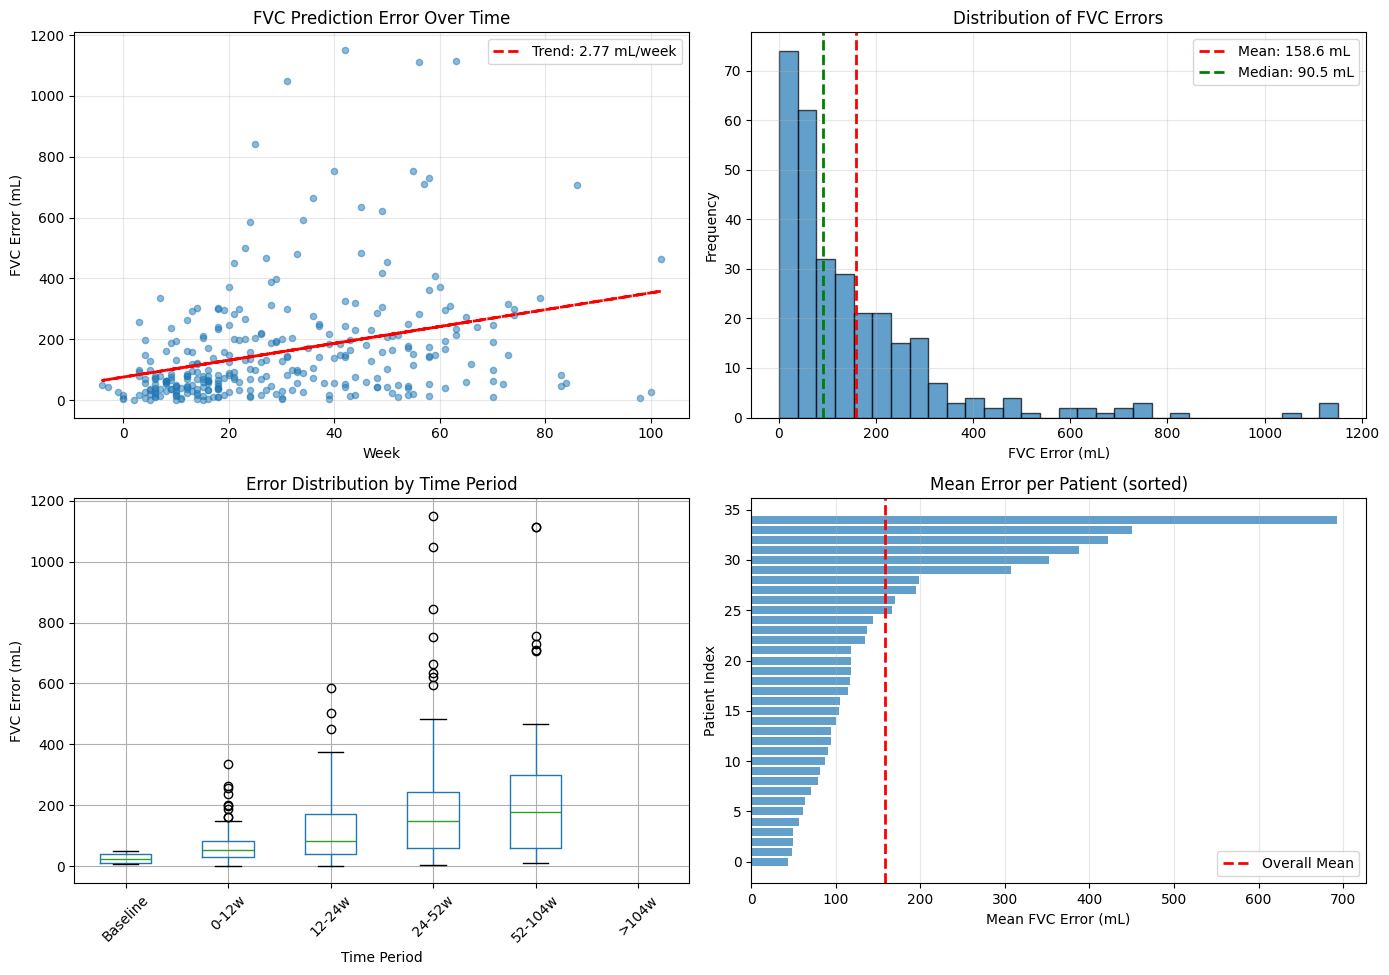

In [ ]:
"""
FVC Error Analysis: Group by timepoint ranges and visualize
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the combined dataframe from the detailed evaluation
# combined = pd.concat([evaluate_fvc_detailed(pid) for pid in test_patients])

def analyze_fvc_errors_by_time(combined_df):
    """
    Analyze FVC prediction errors grouped by time ranges
    """

    print("="*80)
    print("FVC PREDICTION ERROR ANALYSIS BY TIMEPOINT")
    print("="*80)

    # Create time bins
    combined_df['week_bin'] = pd.cut(
        combined_df['week'],
        bins=[-10, 0, 12, 24, 52, 104, 200],
        labels=['Baseline', '0-12w', '12-24w', '24-52w', '52-104w', '>104w']
    )

    # Group by bins
    binned_stats = combined_df.groupby('week_bin')['error'].agg([
        'count', 'mean', 'std', 'median', 'min', 'max'
    ])

    print("\n📊 ERRORS BY TIME PERIOD:")
    print(binned_stats.to_string())

    # Overall statistics
    print("\n" + "="*80)
    print("OVERALL STATISTICS")
    print("="*80)
    print(f"Total measurements:     {len(combined_df)}")
    print(f"Unique patients:        {combined_df['patient_id'].nunique()}")
    print(f"Unique timepoints:      {combined_df['week'].nunique()}")
    print(f"\nMean error:            {combined_df['error'].mean():.2f} mL")
    print(f"Median error:          {combined_df['error'].median():.2f} mL")
    print(f"Std error:             {combined_df['error'].std():.2f} mL")
    print(f"Min error:             {combined_df['error'].min():.2f} mL")
    print(f"Max error:             {combined_df['error'].max():.2f} mL")

    # Percentiles
    print(f"\n25th percentile:       {combined_df['error'].quantile(0.25):.2f} mL")
    print(f"75th percentile:       {combined_df['error'].quantile(0.75):.2f} mL")
    print(f"90th percentile:       {combined_df['error'].quantile(0.90):.2f} mL")

    # Common timepoints with enough data
    print("\n" + "="*80)
    print("MOST COMMON TIMEPOINTS (>5 measurements)")
    print("="*80)

    timepoint_stats = combined_df.groupby('week')['error'].agg([
        'count', 'mean', 'std'
    ]).sort_values('count', ascending=False)

    common_timepoints = timepoint_stats[timepoint_stats['count'] >= 5]
    if len(common_timepoints) > 0:
        print(common_timepoints.head(10).to_string())
    else:
        print("No timepoints with ≥5 measurements")
        print("\nTop 10 timepoints by frequency:")
        print(timepoint_stats.head(10).to_string())

    # Check if error grows with time (it should for slope-based predictions)
    print("\n" + "="*80)
    print("ERROR GROWTH OVER TIME")
    print("="*80)

    correlation = combined_df[['week', 'error']].corr().iloc[0, 1]
    print(f"Correlation (week vs error): {correlation:.3f}")

    if correlation > 0.5:
        print("✓ Error grows with time (expected for slope-based predictions)")
    elif correlation > 0:
        print("~ Weak positive correlation")
    else:
        print("⚠️  Error doesn't grow with time (unexpected!)")

    # Fit a line to see error growth rate
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        combined_df['week'], combined_df['error']
    )
    print(f"Error growth rate:       {slope:.2f} mL per week")
    print(f"Baseline error (week 0): {intercept:.2f} mL")
    print(f"R²:                      {r_value**2:.3f}")

    # ========================================================================
    # Visualizations
    # ========================================================================

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Error vs Week (scatter)
    ax1 = axes[0, 0]
    ax1.scatter(combined_df['week'], combined_df['error'], alpha=0.5, s=20)
    ax1.plot(combined_df['week'], slope * combined_df['week'] + intercept,
             'r--', linewidth=2, label=f'Trend: {slope:.2f} mL/week')
    ax1.set_xlabel('Week')
    ax1.set_ylabel('FVC Error (mL)')
    ax1.set_title('FVC Prediction Error Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Error distribution
    ax2 = axes[0, 1]
    ax2.hist(combined_df['error'], bins=30, edgecolor='black', alpha=0.7)
    ax2.axvline(combined_df['error'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {combined_df["error"].mean():.1f} mL')
    ax2.axvline(combined_df['error'].median(), color='green', linestyle='--',
                linewidth=2, label=f'Median: {combined_df["error"].median():.1f} mL')
    ax2.set_xlabel('FVC Error (mL)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of FVC Errors')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Boxplot by time bin
    ax3 = axes[1, 0]
    combined_df.boxplot(column='error', by='week_bin', ax=ax3)
    ax3.set_xlabel('Time Period')
    ax3.set_ylabel('FVC Error (mL)')
    ax3.set_title('Error Distribution by Time Period')
    plt.sca(ax3)
    plt.xticks(rotation=45)
    ax3.get_figure().suptitle('')  # Remove default title

    # Plot 4: Per-patient error distribution
    ax4 = axes[1, 1]
    patient_errors = combined_df.groupby('patient_id')['error'].mean().sort_values()
    ax4.barh(range(len(patient_errors)), patient_errors.values, alpha=0.7)
    ax4.axvline(combined_df['error'].mean(), color='red', linestyle='--',
                linewidth=2, label='Overall Mean')
    ax4.set_xlabel('Mean FVC Error (mL)')
    ax4.set_ylabel('Patient Index')
    ax4.set_title('Mean Error per Patient (sorted)')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('fvc_error_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved visualization to 'fvc_error_analysis.png'")

    return combined_df, binned_stats


# ============================================================================
# USAGE
# ============================================================================

# First, collect detailed results
def collect_detailed_results(test_predictor, test_patients):
    """Collect per-timepoint FVC predictions"""
    all_results = []

    for patient_id in test_patients:
        if patient_id not in test_predictor.patient_data:
            continue

        predicted_slope = test_predictor.predict_patient_slope(patient_id)
        actual_fvc = test_predictor.patient_data_fvc[patient_id]['fvc']
        patient_weeks = test_predictor.patient_data_fvc[patient_id]['weeks']

        for week, actual_fvc_value in zip(patient_weeks, actual_fvc):
            fvc_predicted = test_predictor.predict_fvc_at_week(
                patient_id, week, predicted_slope
            )
            fvc_error = abs(fvc_predicted - actual_fvc_value)

            all_results.append({
                'patient_id': patient_id,
                'week': week,
                'fvc_true': actual_fvc_value,
                'fvc_pred': fvc_predicted,
                'error': fvc_error
            })

    return pd.DataFrame(all_results)


# Run the analysis
print("Collecting detailed FVC predictions...")
combined_df = collect_detailed_results(test_predictor, test_patients)

print(f"Collected {len(combined_df)} FVC predictions\n")

# Analyze
combined_df, binned_stats = analyze_fvc_errors_by_time(combined_df)

# Save detailed results
combined_df.to_csv('fvc_predictions_detailed.csv', index=False)
print("✓ Saved detailed results to 'fvc_predictions_detailed.csv'")

In [ ]:
print("\n" + "="*80)
print("BASELINE COMPARISON (Predict Mean Slope)")
print("="*80)

# Compute baseline
train_slopes = [patient_data[pid]['slope'] for pid in cv_patients]
mean_train_slope = np.mean(train_slopes)

def baseline_fvc_error_detailed(patient_id):
    intercept = patient_data[patient_id]['intercept']
    actual_fvc = test_patient_data[patient_id]['fvc']
    patient_weeks = test_patient_data[patient_id]['weeks']

    errors = []
    for week, actual_fvc_value in zip(patient_weeks, actual_fvc):
        fvc_pred_baseline = mean_train_slope * week + intercept
        errors.append(abs(fvc_pred_baseline - actual_fvc_value))
    return errors

# Collect baseline errors
baseline_results = []
for patient_id in test_patients:
    if patient_id not in test_patient_data:
        continue
    errors = baseline_fvc_error_detailed(patient_id)
    weeks = test_patient_data[patient_id]['weeks']
    for week, error in zip(weeks, errors):
        baseline_results.append({'week': week, 'error': error})

baseline_df = pd.DataFrame(baseline_results)

print(f"Baseline mean error:  {baseline_df['error'].mean():.2f} mL")
print(f"Your model mean error: {combined_df['error'].mean():.2f} mL")
print(f"\nImprovement: {((baseline_df['error'].mean() - combined_df['error'].mean()) / baseline_df['error'].mean())*100:.1f}%")


BASELINE COMPARISON (Predict Mean Slope)
Baseline mean error:  159.70 mL
Your model mean error: 158.58 mL

Improvement: 0.7%


# Use Stratified Splitting

In [ ]:
import os
import json
import copy
import numpy as np
import torch
import glob
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold

# Configuration
CSV_PATH = '/content/drive/MyDrive/train_with_coefs.csv'
NPY_DIR = '/content/drive/MyDrive/extracted_npy/extracted_npy'
TARGET_WEEK = 52
PROGRESSION_THRESHOLD = 0.10
EPOCHS_PER_FOLD = 30
IMAGE_SIZE = (224, 224)
N_FOLDS = 5
K = 4  # patients per batch
CHECKPOINT_DIR = '/content/drive/MyDrive/checkpoints_kfold_with_npy_stratified'

print("="*70)
print("IPF SLOPE PREDICTION - K-FOLD CROSS-VALIDATION")
print("="*70)

# ============================================================================
# STEP 1: Load data
# ============================================================================

print("\n[1/5] Loading data from CSV...")
data_loader = IPFDataLoader(CSV_PATH,npy_dir=NPY_DIR)
patient_data = data_loader.get_patient_data()

all_patients = list(patient_data.keys())
print(f"Total patients: {len(all_patients)}")

# ============================================================================
# STEP 2: Split test set (20% held out)
# ============================================================================
print("\n[2/5] Splitting data...")
train_patients, test_patients = stratified_split_by_fvc(patient_data)
test_size = int(0.2 * len(all_patients))
np.random.seed(42)
np.random.shuffle(all_patients)

test_patients = all_patients[:test_size]
cv_patients = all_patients[test_size:]

print(f"✓ CV patients: {len(cv_patients)} (for {N_FOLDS}-fold CV)")
print(f"✓ Test patients: {len(test_patients)} (held out)")


# ============================================================================
# STEP 3: K-Fold Cross-Validation
# ============================================================================

print(f"\n[3/5] Running {N_FOLDS}-fold cross-validation...")

# Check for overall progress file
progress_file = f'{CHECKPOINT_DIR}/kfold_progress.json'
completed_folds = set()

if os.path.exists(progress_file):
    import json
    with open(progress_file, 'r') as f:
        progress_data = json.load(f)
        completed_folds = set(progress_data.get('completed_folds', []))
    print(f"Found existing progress: {len(completed_folds)} folds completed")
    print(f"   Completed folds: {sorted(completed_folds)}")

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

# Load existing results if available
results_file = f'{CHECKPOINT_DIR}/fold_results_partial.json'
if os.path.exists(results_file):
    import json
    with open(results_file, 'r') as f:
        fold_results = json.load(f)
    print(f"✓ Loaded {len(fold_results)} previous fold results")

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(cv_patients)):
    # Skip if fold already completed
    if (fold_idx + 1) in completed_folds:
        print(f"\n Skipping Fold {fold_idx+1}/{N_FOLDS} (already completed)")
        continue
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")

    # Get patient lists
    fold_train_patients = [cv_patients[i] for i in train_idx]
    fold_val_patients = [cv_patients[i] for i in val_idx]

    print(f"Train: {len(fold_train_patients)} patients")
    print(f"Val:   {len(fold_val_patients)} patients")

    # Create datasets
    fold_train_dataset = IPFSliceDataset(
        fold_train_patients, patient_data,
        normalize_slope=False, image_size=IMAGE_SIZE
    )
    fold_val_dataset = IPFSliceDataset(
        fold_val_patients, patient_data,
        normalize_slope=False, image_size=IMAGE_SIZE
    )
    fold_val_dataset.slope_scaler = fold_train_dataset.slope_scaler

    # Create data loaders
    fold_train_loader = DataLoader(
        fold_train_dataset,
        num_workers=4,
        pin_memory=True,
        batch_sampler=PatientBatchSampler(
            fold_train_dataset,
            patients_per_batch=K,
            shuffle=True  # ✓ Shuffle for training
        ),
        collate_fn=patient_group_collate,
    )

    fold_val_loader = DataLoader(
        fold_val_dataset,
        num_workers=4,
        pin_memory=True,
        batch_sampler=PatientBatchSampler(
            fold_val_dataset,
            patients_per_batch=K,
            shuffle=False  # ✓ NO shuffle for validation
        ),
        collate_fn=patient_group_collate,
    )

    # Initialize model and trainer
    model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=True)
    trainer = SlopeTrainer(model)

    # Create checkpoint directory for this fold
    fold_checkpoint_dir = f'{CHECKPOINT_DIR}/fold_{fold_idx+1}'
    os.makedirs(fold_checkpoint_dir, exist_ok=True)

    # Check for existing checkpoint
    fold_checkpoint_path = f'{fold_checkpoint_dir}/last_checkpoint.pth'
    start_epoch = 0
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    max_patience = 10

    if os.path.exists(fold_checkpoint_path):
        print(f"\n Found checkpoint for fold {fold_idx+1}, loading...")
        checkpoint = torch.load(fold_checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        trainer.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        patience_counter = checkpoint['patience_counter']

        # Load best model state if it exists
        best_model_path = f'{fold_checkpoint_dir}/best_model.pth'
        if os.path.exists(best_model_path):
            best_model_state = torch.load(best_model_path)['model_state_dict']

        print(f"✓ Resumed from epoch {start_epoch}, best val loss: {best_val_loss:.6f}")

    # Training loop with early stopping
    for epoch in range(start_epoch, EPOCHS_PER_FOLD):
        train_loss = trainer.train_epoch(fold_train_loader)
        val_loss = trainer.validate(fold_val_loader)

        if epoch % 5 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS_PER_FOLD} - "
                  f"Train: {train_loss:.6f}, Val: {val_loss:.6f}")

        trainer.scheduler.step(val_loss)

        # Update best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

            # Save best model
            torch.save({
                'model_state_dict': best_model_state,
                'val_loss': best_val_loss,
                'epoch': epoch
            }, f'{fold_checkpoint_dir}/best_model.pth')
            print(f"  ✓ New best model saved (val_loss: {best_val_loss:.6f})")
        else:
            patience_counter += 1

        # Save checkpoint every epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'scheduler_state_dict': trainer.scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'train_loss': train_loss,
            'val_loss': val_loss
        }, fold_checkpoint_path)

        # Early stopping
        if patience_counter >= max_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


    print(f"\n✓ Fold {fold_idx+1} Results:")
    print(f"  Best Val Loss: {best_val_loss:.6f}")


    fold_results.append({
        'fold': fold_idx + 1,
        'val_loss': best_val_loss,

        'n_train': len(fold_train_patients),
        'n_val': len(fold_val_patients)
    })

    # Mark fold as completed and save progress
    completed_folds.add(fold_idx + 1)

import json
with open(progress_file, 'w') as f:
    json.dump({'completed_folds': list(completed_folds)}, f)

# Save partial results
with open(results_file, 'w') as f:
    json.dump(fold_results, f, indent=2)

print(f"✓ Fold {fold_idx+1} completed and saved. Progress: {len(completed_folds)}/{N_FOLDS} folds")


IPF SLOPE PREDICTION - K-FOLD CROSS-VALIDATION

[1/5] Loading data from CSV...
✅ Loaded 1549 records from CSV
✅ Unique patients in CSV: 176
✅ NPY directory: /content/drive/MyDrive/extracted_npy/extracted_npy
📋 Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus', 'slice_files', 'fvc_slope', 'fvc_intercept0']
✅ 176 pazienti con dati completi (CSV + NPY)

📊 Patient data prepared for 176 patients
   Min slices: 4
   Max slices: 11
   Avg slices: 10.20
Total patients: 176

[2/5] Splitting data...

📊 Stratification bins (poly0_coef):
  Bin 0: [-28, -8] - 44 patients
  Bin 1: [-8, -4] - 44 patients
  Bin 2: [-4, -1] - 44 patients
  Bin 3: [-1, 15] - 44 patients

✓ Train slope: -4.69 ± 6.43
✓ Test slope:  -3.87 ± 4.65
✓ CV patients: 141 (for 5-fold CV)
✓ Test patients: 35 (held out)

[3/5] Running 5-fold cross-validation...

FOLD 1/5
Train: 112 patients
Val:   29 patients
Dataset created with 1150 slices from 112 patients
Dataset created with 288 slices from 29 patien

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Training: 100%|██████████| 28/28 [01:20<00:00,  2.88s/it]


Epoch 1/30 - Train: 40.916056, Val: 25.651584
  ✓ New best model saved (val_loss: 25.651584)


Training: 100%|██████████| 28/28 [00:06<00:00,  4.38it/s]


Epoch 6/30 - Train: 37.127553, Val: 28.804045


...

Epoch 16/30 - Train: 37.696931, Val: 17.664722


Training: 100%|██████████| 29/29 [00:06<00:00,  4.51it/s]


Epoch 21/30 - Train: 36.609527, Val: 15.716181


Training: 100%|██████████| 29/29 [00:06<00:00,  4.31it/s]


Early stopping at epoch 22

✓ Fold 5 Results:
  Best Val Loss: 14.534017
✓ Fold 5 completed and saved. Progress: 5/5 folds


In [ ]:

# ============================================================================
# STEP 6: Final evaluation on test set
# ============================================================================

print(f"\n[5/5] Evaluating on held-out test set...")

test_dataset = IPFSliceDataset(
    test_patients, patient_data,
    normalize_slope=False, image_size=IMAGE_SIZE
)
test_dataset.slope_scaler = final_train_dataset.slope_scaler

test_predictor = ProgressionPredictor(final_model, test_dataset, patient_data, test_patient_data)

mean_fvc_error = test_predictor.evaluate_test_set(test_patients)

print(f"\nMean FVC prediction error across all test patients: {mean_fvc_error:.2f}")




[5/5] Evaluating on held-out test set...
Dataset created with 357 slices from 35 patients


Evaluating patients: 100%|██████████| 35/35 [00:04<00:00,  7.66it/s]


Mean FVC prediction error across all test patients: 160.74


Collected 306 FVC predictions

FVC PREDICTION ERROR ANALYSIS BY TIMEPOINT

📊 ERRORS BY TIME PERIOD:
          count        mean         std      median       min          max
week_bin                                                                  
Baseline      6   24.935896   18.714254   22.006435  4.997369    49.885890
0-12w        70   71.990529   68.772036   51.959825  0.689002   336.257443
12-24w       81  125.066064  119.531230   80.702687  0.683376   584.607937
24-52w       96  209.312595  217.594524  148.291550  3.181688  1151.343506
52-104w      53  247.400095  254.596065  176.234215  8.544995  1113.823776
>104w         0         NaN         NaN         NaN       NaN          NaN

OVERALL STATISTICS
Total measurements:     306
Unique patients:        35
Unique timepoints:      79

Mean error:            158.58 mL
Median error:          90.53 mL
Std error:             187.55 mL
Min error:             0.68 mL
Max error:             1151.34 mL

25th percentile:       41.62 mL
7

/tmp/ipython-input-36719198.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = combined_df.groupby('week_bin')['error'].agg([



✓ Saved visualization to 'fvc_error_analysis.png'
✓ Saved detailed results to 'fvc_predictions_detailed.csv'


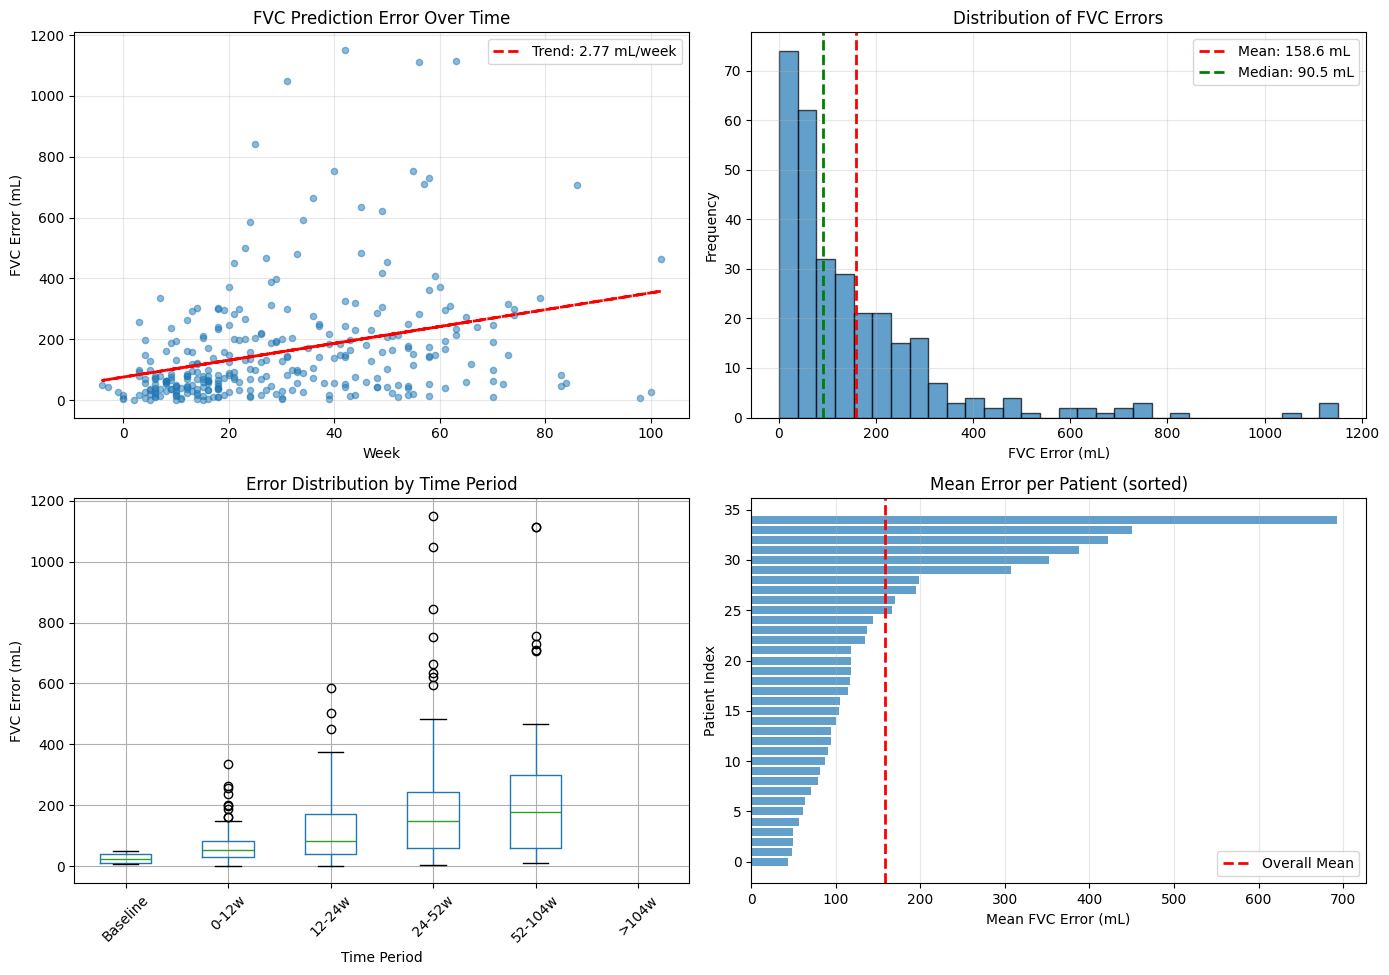

In [ ]:
"""
FVC Error Analysis: Group by timepoint ranges and visualize
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the combined dataframe from the detailed evaluation
# combined = pd.concat([evaluate_fvc_detailed(pid) for pid in test_patients])

def analyze_fvc_errors_by_time(combined_df):
    """
    Analyze FVC prediction errors grouped by time ranges
    """

    print("="*80)
    print("FVC PREDICTION ERROR ANALYSIS BY TIMEPOINT")
    print("="*80)

    # Create time bins
    combined_df['week_bin'] = pd.cut(
        combined_df['week'],
        bins=[-10, 0, 12, 24, 52, 104, 200],
        labels=['Baseline', '0-12w', '12-24w', '24-52w', '52-104w', '>104w']
    )

    # Group by bins
    binned_stats = combined_df.groupby('week_bin')['error'].agg([
        'count', 'mean', 'std', 'median', 'min', 'max'
    ])

    print("\n📊 ERRORS BY TIME PERIOD:")
    print(binned_stats.to_string())

    # Overall statistics
    print("\n" + "="*80)
    print("OVERALL STATISTICS")
    print("="*80)
    print(f"Total measurements:     {len(combined_df)}")
    print(f"Unique patients:        {combined_df['patient_id'].nunique()}")
    print(f"Unique timepoints:      {combined_df['week'].nunique()}")
    print(f"\nMean error:            {combined_df['error'].mean():.2f} mL")
    print(f"Median error:          {combined_df['error'].median():.2f} mL")
    print(f"Std error:             {combined_df['error'].std():.2f} mL")
    print(f"Min error:             {combined_df['error'].min():.2f} mL")
    print(f"Max error:             {combined_df['error'].max():.2f} mL")

    # Percentiles
    print(f"\n25th percentile:       {combined_df['error'].quantile(0.25):.2f} mL")
    print(f"75th percentile:       {combined_df['error'].quantile(0.75):.2f} mL")
    print(f"90th percentile:       {combined_df['error'].quantile(0.90):.2f} mL")

    # Common timepoints with enough data
    print("\n" + "="*80)
    print("MOST COMMON TIMEPOINTS (>5 measurements)")
    print("="*80)

    timepoint_stats = combined_df.groupby('week')['error'].agg([
        'count', 'mean', 'std'
    ]).sort_values('count', ascending=False)

    common_timepoints = timepoint_stats[timepoint_stats['count'] >= 5]
    if len(common_timepoints) > 0:
        print(common_timepoints.head(10).to_string())
    else:
        print("No timepoints with ≥5 measurements")
        print("\nTop 10 timepoints by frequency:")
        print(timepoint_stats.head(10).to_string())

    # Check if error grows with time (it should for slope-based predictions)
    print("\n" + "="*80)
    print("ERROR GROWTH OVER TIME")
    print("="*80)

    correlation = combined_df[['week', 'error']].corr().iloc[0, 1]
    print(f"Correlation (week vs error): {correlation:.3f}")

    if correlation > 0.5:
        print("✓ Error grows with time (expected for slope-based predictions)")
    elif correlation > 0:
        print("~ Weak positive correlation")
    else:
        print("⚠️  Error doesn't grow with time (unexpected!)")

    # Fit a line to see error growth rate
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        combined_df['week'], combined_df['error']
    )
    print(f"Error growth rate:       {slope:.2f} mL per week")
    print(f"Baseline error (week 0): {intercept:.2f} mL")
    print(f"R²:                      {r_value**2:.3f}")

    # ========================================================================
    # Visualizations
    # ========================================================================

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Error vs Week (scatter)
    ax1 = axes[0, 0]
    ax1.scatter(combined_df['week'], combined_df['error'], alpha=0.5, s=20)
    ax1.plot(combined_df['week'], slope * combined_df['week'] + intercept,
             'r--', linewidth=2, label=f'Trend: {slope:.2f} mL/week')
    ax1.set_xlabel('Week')
    ax1.set_ylabel('FVC Error (mL)')
    ax1.set_title('FVC Prediction Error Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Error distribution
    ax2 = axes[0, 1]
    ax2.hist(combined_df['error'], bins=30, edgecolor='black', alpha=0.7)
    ax2.axvline(combined_df['error'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {combined_df["error"].mean():.1f} mL')
    ax2.axvline(combined_df['error'].median(), color='green', linestyle='--',
                linewidth=2, label=f'Median: {combined_df["error"].median():.1f} mL')
    ax2.set_xlabel('FVC Error (mL)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of FVC Errors')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Boxplot by time bin
    ax3 = axes[1, 0]
    combined_df.boxplot(column='error', by='week_bin', ax=ax3)
    ax3.set_xlabel('Time Period')
    ax3.set_ylabel('FVC Error (mL)')
    ax3.set_title('Error Distribution by Time Period')
    plt.sca(ax3)
    plt.xticks(rotation=45)
    ax3.get_figure().suptitle('')  # Remove default title

    # Plot 4: Per-patient error distribution
    ax4 = axes[1, 1]
    patient_errors = combined_df.groupby('patient_id')['error'].mean().sort_values()
    ax4.barh(range(len(patient_errors)), patient_errors.values, alpha=0.7)
    ax4.axvline(combined_df['error'].mean(), color='red', linestyle='--',
                linewidth=2, label='Overall Mean')
    ax4.set_xlabel('Mean FVC Error (mL)')
    ax4.set_ylabel('Patient Index')
    ax4.set_title('Mean Error per Patient (sorted)')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('fvc_error_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved visualization to 'fvc_error_analysis.png'")

    return combined_df, binned_stats


# ============================================================================
# USAGE
# ============================================================================

# First, collect detailed results
def collect_detailed_results(test_predictor, test_patients):
    """Collect per-timepoint FVC predictions"""
    all_results = []

    for patient_id in test_patients:
        if patient_id not in test_predictor.patient_data:
            continue

        predicted_slope = test_predictor.predict_patient_slope(patient_id)
        actual_fvc = test_predictor.patient_data_fvc[patient_id]['fvc']
        patient_weeks = test_predictor.patient_data_fvc[patient_id]['weeks']

        for week, actual_fvc_value in zip(patient_weeks, actual_fvc):
            fvc_predicted = test_predictor.predict_fvc_at_week(
                patient_id, week, predicted_slope
            )
            fvc_error = abs(fvc_predicted - actual_fvc_value)

            all_results.append({
                'patient_id': patient_id,
                'week': week,
                'fvc_true': actual_fvc_value,
                'fvc_pred': fvc_predicted,
                'error': fvc_error
            })

    return pd.DataFrame(all_results)


# Run the analysis
print("Collecting detailed FVC predictions...")
combined_df = collect_detailed_results(test_predictor, test_patients)

print(f"Collected {len(combined_df)} FVC predictions\n")

# Analyze
combined_df, binned_stats = analyze_fvc_errors_by_time(combined_df)

# Save detailed results
combined_df.to_csv('fvc_predictions_detailed.csv', index=False)
print("✓ Saved detailed results to 'fvc_predictions_detailed.csv'")